In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch 


In [18]:
data = [torch.randn(20) for _ in range(100)]
import numpy as np

data_L = [np.random.randn(20) for _ in range(100)]

data_np = np.random.randn(100,20)
import pandas as pd
data_df = pd.DataFrame(data_np)

loader = DataLoader(data_np, batch_size=16)

# loader.dataset
# batch = next(iter(loader))
# print(type(batch))
# print(len(batch))
# print(batch)

In [2]:
"""
Deep Canonical Correlation Analysis (CCA) using `cca_zoo_new`
==========================================================

This script showcases how to implement various Deep CCA methods and their
variants using the `cca_zoo_new` library, a dedicated tool for canonical
correlation analysis and its related techniques. The MNIST dataset is used
as an example, where images are split into two halves to treat as separate representations.

Key Features:
- Demonstrates the training process of multiple Deep CCA variants.
- Visualizes the results of each variant for comparative analysis.
- Leverages `cca_zoo_new` for canonical correlation analysis techniques.
"""


# %%
# Imports
# -------

import lightning.pytorch as pl
from lightning import seed_everything
from matplotlib import pyplot as plt
from cca_zoo_new.deep import (
    DCCA,
    DCCA_EY,
    DCCA_NOI,
    DCCA_SDL,
    BarlowTwins,
    VICReg,
    architectures,
)
from cca_zoo_new.visualisation import (
    ScoreScatterDisplay,
    UMAPScoreDisplay,
    TSNEScoreDisplay,
)
from __init__ import example_mnist_data


To use iterative methods please install pytorch-lightning from version 2.0.0


e:\Anaconda\envs\bio\Lib\site-packages\cca_zoo\_base.py:229: SyntaxWarning: invalid escape sequence '\('
  Mathematically, given two representations \(X_i\), canonical variates


In [29]:
# train_loader, val_loader, train_labels, val_labels
train_loader, val_loader, train_labels, val_labels = example_mnist_data(N_TRAIN, N_VAL)
train_loader.dataset


In [38]:
subset = train_labels.dataset
subset

AttributeError: 'numpy.ndarray' object has no attribute 'dataset'

In [39]:
train_labels

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9, 4, 0,
       9, 1, 1, 2, 4, 3, 2, 7, 3, 8, 6, 9, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9,
       3, 9, 8, 5, 9, 3, 3, 0, 7, 4, 9, 8, 0, 9, 4, 1, 4, 4, 6, 0, 4, 5,
       6, 1, 0, 0, 1, 7, 1, 6, 3, 0, 2, 1, 1, 7, 9, 0, 2, 6, 7, 8, 3, 9,
       0, 4, 6, 7, 4, 6, 8, 0, 7, 8, 3, 1, 5, 7, 1, 7, 1, 1, 6, 3, 0, 2,
       9, 3, 1, 1, 0, 4, 9, 2, 0, 0, 2, 0, 2, 7, 1, 8, 6, 4, 1, 6, 3, 4,
       5, 9, 1, 3, 3, 8, 5, 4, 7, 7, 4, 2, 8, 5, 8, 6, 7, 3, 4, 6, 1, 9,
       9, 6, 0, 3, 7, 2, 8, 2, 9, 4, 4, 6, 4, 9, 7, 0, 9, 2, 9, 5, 1, 5,
       9, 1, 2, 3, 2, 3, 5, 9, 1, 7, 6, 2, 8, 2, 2, 5, 0, 7, 4, 9, 7, 8,
       3, 2, 1, 1, 8, 3, 6, 1, 0, 3, 1, 0, 0, 1, 7, 2, 7, 3, 0, 4, 6, 5,
       2, 6, 4, 7, 1, 8, 9, 9, 3, 0, 7, 1, 0, 2, 0, 3, 5, 4, 6, 5, 8, 6,
       3, 7, 5, 8, 0, 9, 1, 0, 3, 1, 2, 2, 3, 3, 6, 4, 7, 5, 0, 6, 2, 7,
       9, 8, 5, 9, 2, 1, 1, 4, 4, 5, 6, 4, 1, 2, 5, 3, 9, 3, 9, 0, 5, 9,
       6, 5, 7, 4, 1, 3, 4, 0, 4, 8, 0, 4, 3, 6, 8,

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
e:\Anaconda\envs\bio\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_R

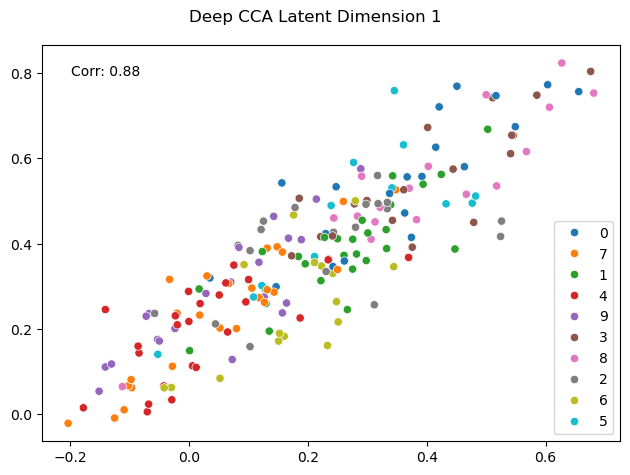

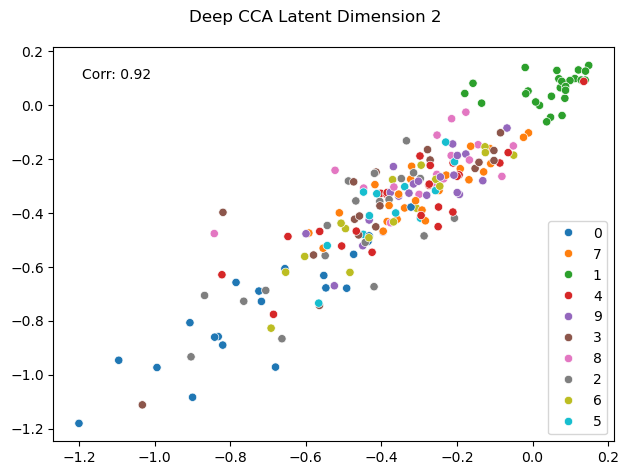

In [3]:

# %%
# Data
# -----
# We use the MNIST dataset as an example of two representations of the same data.
# We split the images into two halves and treat them as separate representations.

seed_everything(42)
LATENT_DIMS = 2  # The dimensionality of the latent space
EPOCHS = 10  # The number of epochs to train the models
N_TRAIN = 1000  # The number of training samples
N_VAL = 200  # The number of validation samples
train_loader, val_loader, train_labels, val_labels = example_mnist_data(N_TRAIN, N_VAL)

encoder_1 = architectures.Encoder(latent_dimensions=LATENT_DIMS, feature_size=392)
encoder_2 = architectures.Encoder(latent_dimensions=LATENT_DIMS, feature_size=392)

# %%
# Deep CCA
# ----------------------------
# Deep CCA is a method that learns nonlinear transformations of two representations
# such that the resulting latent representations are maximally correlated.

dcca = DCCA(latent_dimensions=LATENT_DIMS, encoders=[encoder_1, encoder_2])
trainer = pl.Trainer(
    max_epochs=EPOCHS,
    enable_checkpointing=False,
    enable_model_summary=False,
    enable_progress_bar=False,
)
trainer.fit(dcca, train_loader, val_loader)
# Visualizing the Latent Space
# ----------------------------
# After training, we can visualize the learned representations in the latent space.
# For this, we provide three options: Scatter, UMAP and t-SNE.

# Scatterplot of the latent space
score_display = ScoreScatterDisplay.from_estimator(
    dcca, val_loader, labels=val_labels.astype(str)
)
score_display.plot(title="Deep CCA")
plt.show()


# Multiview

In [40]:
from cca_zoo_new.deep import DCCA, architectures
from cca_zoo_new.deep.data import NumpyDataset, check_dataset, get_dataloaders

X = np.random.normal(size=(100, 10))
Y = np.random.normal(size=(100, 20))

In [41]:
numpy_dataset = NumpyDataset([X, Y])

# %%
# Dataset Validation
# ------------------
# Before proceeding, it's a good practice to validate the constructed dataset.
# The `check_dataset` function ensures that the dataset adheres to CCA-Zoo's
# expected format.

check_dataset(numpy_dataset)

# %%
# Creating a Custom Dataset Class
# -------------------------------
# For advanced users or specific requirements, one can create a custom dataset class.
# The new class should inherit from the native `torch.utils.data.Dataset` class.
# The class must implement the `__getitem__` method to return a tuple consisting
# of multiple representations and an associated label, where representations are represented as torch tensors.


class CustomDataset(torch.utils.data.Dataset):
    def __init__(self):
        pass

    def __len__(self):
        return 10

    def __getitem__(self, index):
        return {"views": (torch.rand(10), torch.rand(10))}


custom_dataset = CustomDataset()
check_dataset(custom_dataset)

# %%
# Convert Custom Dataset into DataLoader
# --------------------------------------
# The `get_dataloaders` function can now be used to transform the custom dataset
# into dataloaders suitable for CCA-Zoo.

train_loader = get_dataloaders(custom_dataset, batch_size=2)

# %%
# Training with Deep CCA
# -----------------------
# Once the dataloaders are set, it's time to configure and train a Deep CCA model.

LATENT_DIMS = 1
EPOCHS = 10

encoder_1 = architectures.Encoder(latent_dimensions=LATENT_DIMS, feature_size=10)
encoder_2 = architectures.Encoder(latent_dimensions=LATENT_DIMS, feature_size=10)

dcca = DCCA(latent_dimensions=LATENT_DIMS, encoders=[encoder_1, encoder_2])
trainer = pl.Trainer(
    max_epochs=EPOCHS,
    enable_checkpointing=False,
    enable_model_summary=False,
    enable_progress_bar=False,
)
trainer.fit(dcca, train_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
e:\Anaconda\envs\bio\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
e:\Anaconda\envs\bio\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
e:\Anaconda\envs\bio\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (5) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
e:\Anaconda\envs\bio\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 1 module(s) in eval mode at the start of tr

In [ ]:
x_cca, y_cca = dcca.transform(train_loader)

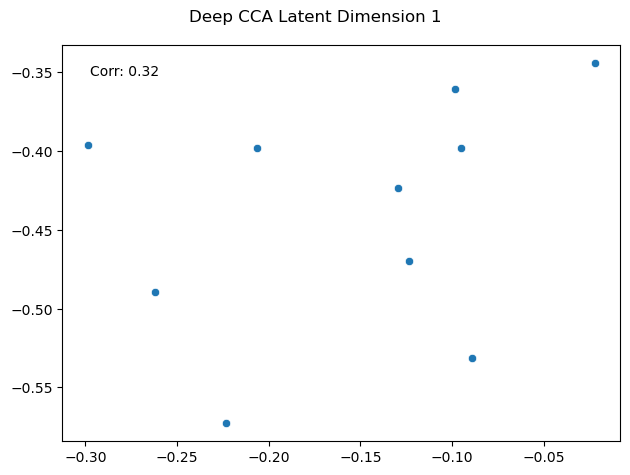

In [42]:
# Scatterplot of the latent space
score_display = ScoreScatterDisplay.from_estimator(
    dcca, train_loader, )
score_display.plot(title="Deep CCA")
plt.show()